In [1]:
# ==========================================================
# A DATA-DRIVEN ANALYSIS OF CRIME RATE
# AND ITS INFLUENCING FACTORS IN INDIA
# ==========================================================
# Authors:
# Suraj Subba (CSD25008)
# Somir Baruah (CSD25005)
# ==========================================================

# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr, ttest_ind
from statsmodels.tsa.arima.model import ARIMA
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix



In [2]:
# ==========================================================
# 2. LOAD DATASET
# ==========================================================

df = pd.read_csv("dataset.csv")

print("First 5 Rows")
df.head()

First 5 Rows


,STATE/UT,population deprived of schooling,poverty rate (%),population deprived of Nutrition,Year,unemployment rate,gdp(billions),literacy rate(%),Population(in lakhs),total crimes,Murder,Kidnapping and Abduction,crime against women,crime against children,crime committed by juveniles
0,Andhra Pradesh,15.80,6.06,22.94,2021,4.2,"9,786",68.5,527.87,222199,956,835,17752,2669,934
1,Arunachal Pradesh,14.20,13.76,17.10,2021,7.7,305,78.4,15.33,3039,49,85,366,162,8
2,Assam,12.35,19.35,31.80,2021,3.8,"3,398",87.2,350.43,133239,1192,7580,29046,5282,206
3,Bihar,22.29,33.70,42.20,2021,6.0,"5,678",73.3,1230.83,282083,2799,10198,17950,6894,732
4,Chattisgarh,10.50,16.37,35.12,2021,2.5,"3,523",70.3,294.93,110633,1007,2681,7344,6001,2004


In [8]:
# ==========================================================
# 3. BASIC INFORMATION
# ==========================================================

print("\nShape of Dataset")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nDataset Information")
print(df.info())



Shape of Dataset
(108, 16)

Columns
Index(['STATE/UT', 'population deprived of schooling', 'poverty rate (%)',
       'population deprived of Nutrition', 'Year', 'unemployment rate',
       'gdp(billions)', 'literacy rate(%)', 'Population(in lakhs)',
       'total crimes', 'Murder', 'Kidnapping and Abduction',
       'crime against women', 'crime against children',
       'crime committed by juveniles', 'Crime per Lakh Population'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   STATE/UT                          108 non-null    object 
 1   population deprived of schooling  108 non-null    float64
 2   poverty rate (%)                  108 non-null    float64
 3   population deprived of Nutrition  108 non-null    float64
 4   Year                           

In [3]:
# ==========================================================
# 4. DATA CLEANING
# ==========================================================

# GDP column cleaning
df['gdp(billions)'] = (
    df['gdp(billions)']
    .astype(str)
    .str.replace(',', '')
)

df['gdp(billions)'] = pd.to_numeric(
    df['gdp(billions)'],
    errors='coerce'
)

# Remove duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

# Missing values
print("\nMissing Values")
print(df.isnull().sum())

# Fill missing numeric values
df.fillna(df.median(numeric_only=True), inplace=True)


Duplicate Rows: 0

Missing Values
STATE/UT                            0
population deprived of schooling    0
poverty rate (%)                    0
population deprived of Nutrition    0
Year                                0
unemployment rate                   0
gdp(billions)                       0
literacy rate(%)                    0
Population(in lakhs)                0
total crimes                        0
Murder                              0
Kidnapping and Abduction            0
crime against women                 0
crime against children              0
crime committed by juveniles        0
dtype: int64


In [4]:
# ==========================================================
# DESCRIPTIVE STATISTICS
# ==========================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
population deprived of schooling,108.0,8.880000,4.785525,1.80,4.5750,8.000,12.4625,22.29
poverty rate (%),108.0,8.663056,7.528595,0.37,2.9700,5.970,11.7225,33.70
population deprived of Nutrition,108.0,25.540833,8.512592,10.36,18.8450,24.155,32.7400,42.20
Year,108.0,2022.000000,0.820303,2021.00,2021.0000,2022.000,2023.0000,2023.00
unemployment rate,108.0,4.750926,2.788343,0.90,2.5750,4.250,6.1000,17.20
gdp(billions),108.0,6607.751019,7777.699827,0.33,389.5000,3642.000,10193.2500,36459.00
literacy rate(%),108.0,82.104259,7.394772,66.40,76.6000,82.330,87.0500,98.20
Population(in lakhs),108.0,382.054722,491.738444,0.68,15.7075,254.865,566.2400,2364.84
total crimes,108.0,168174.305556,214452.154197,97.00,3506.0000,64659.000,252657.5000,793020.00
Murder,108.0,791.805556,902.203590,0.00,29.5000,405.500,1366.2500,3717.00


In [5]:
# ==========================================================
# 5. EXPLORATORY DATA ANALYSIS
# ==========================================================

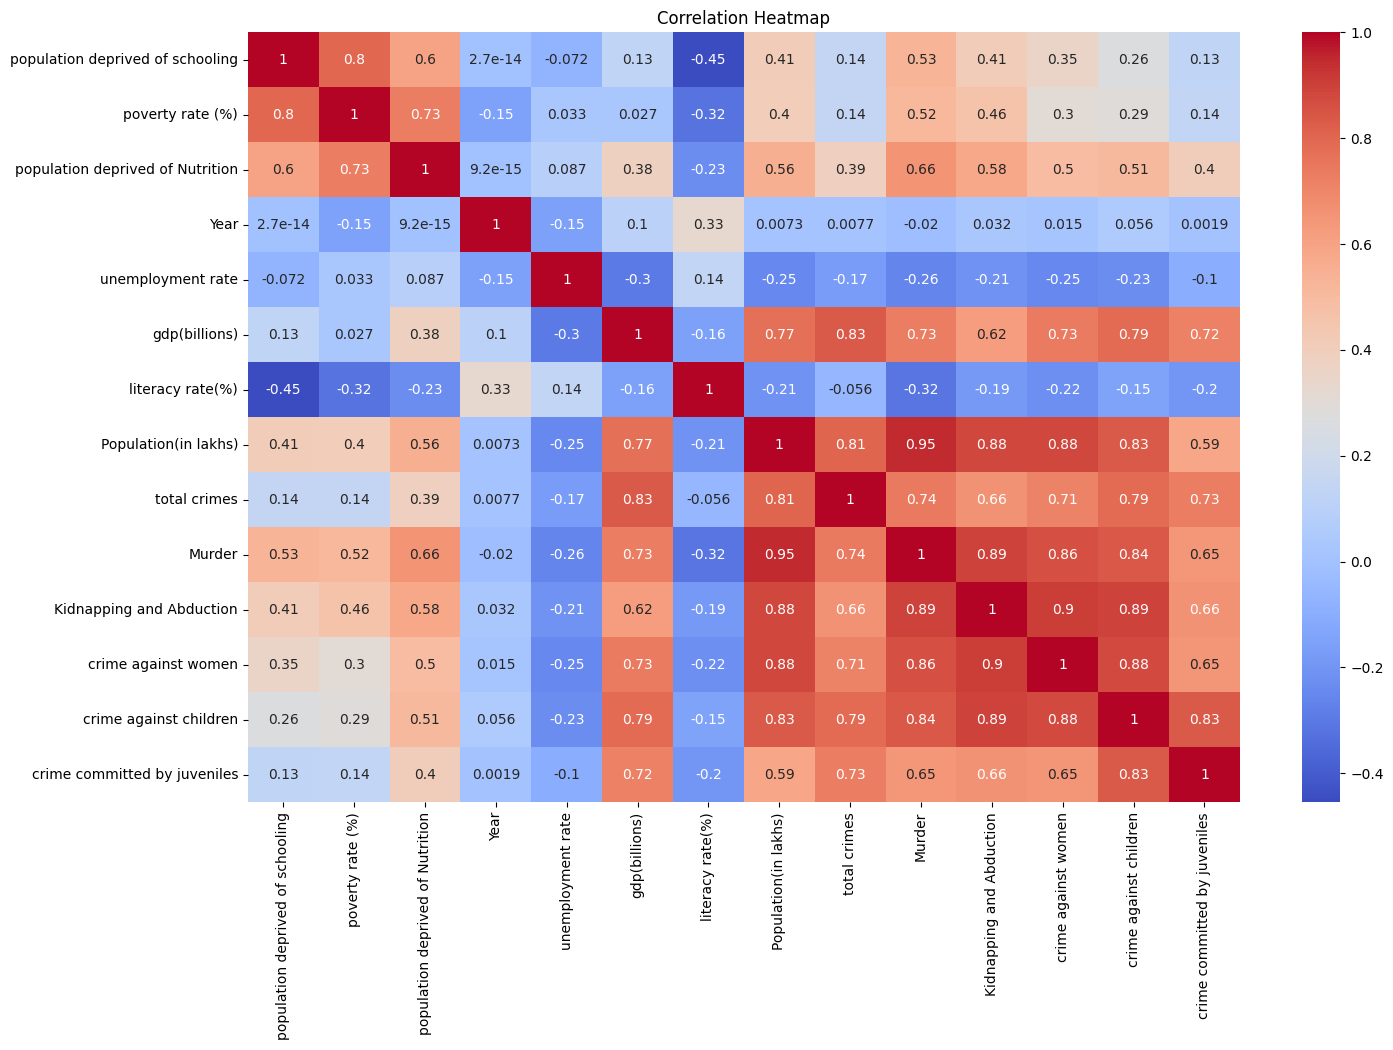

In [6]:
# ==========================================================
# 5.1 Correlation Heatmap
# ==========================================================

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(16,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

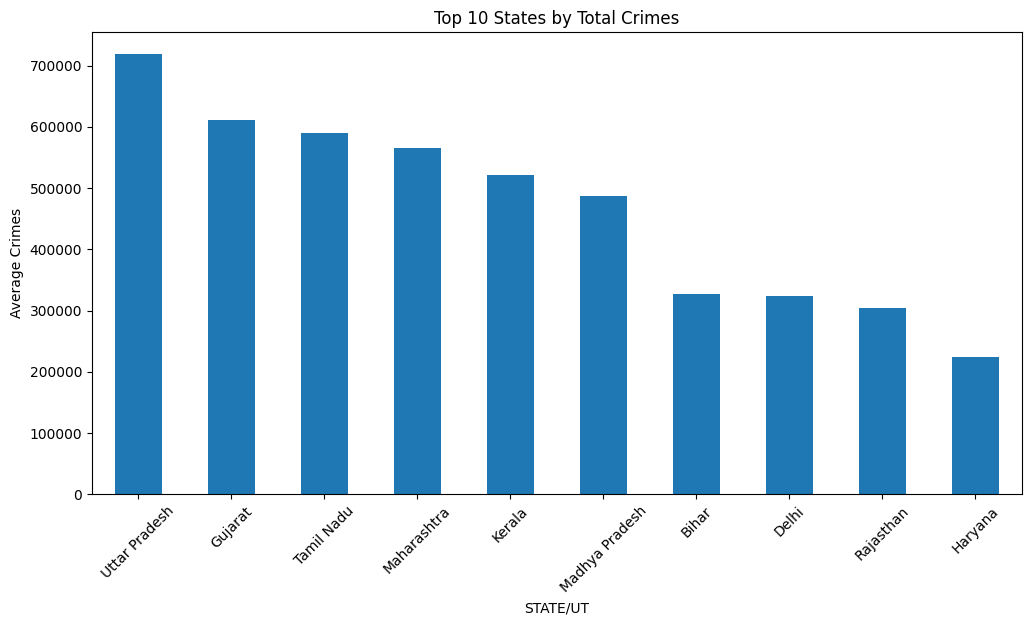

In [7]:
# ==========================================================
# 5.2 Top Crime States
# ==========================================================

crime_state = (
    df.groupby('STATE/UT')['total crimes']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

crime_state.plot(kind='bar')

plt.title("Top 10 States by Total Crimes")
plt.ylabel("Average Crimes")
plt.xticks(rotation=45)

plt.show()

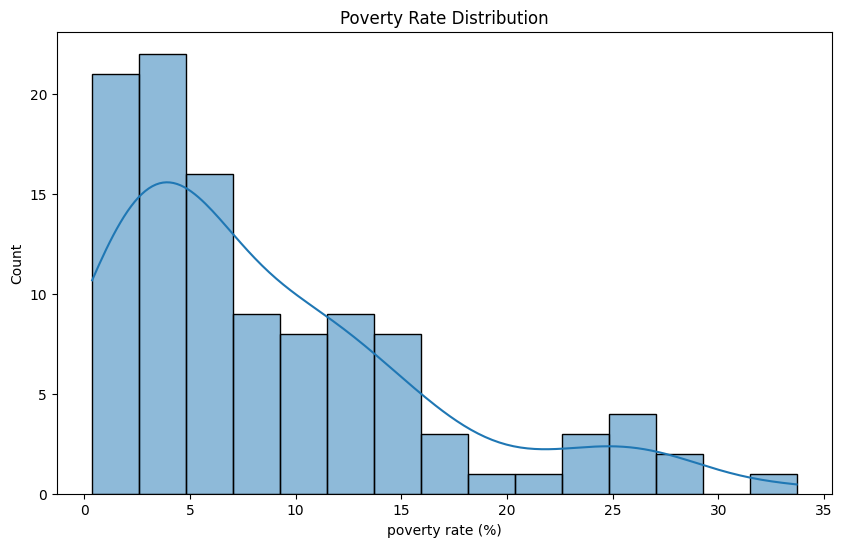

In [8]:
# ==========================================================
# 5.3 Poverty Distribution
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['poverty rate (%)'],
    bins=15,
    kde=True
)

plt.title("Poverty Rate Distribution")
plt.show()

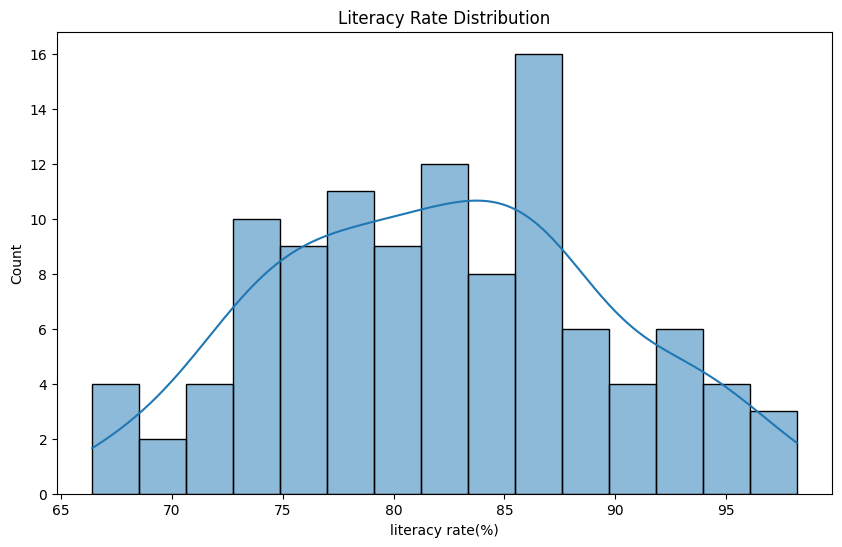

In [9]:
# ==========================================================
# 5.4 Literacy Distribution
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['literacy rate(%)'],
    bins=15,
    kde=True
)

plt.title("Literacy Rate Distribution")
plt.show()

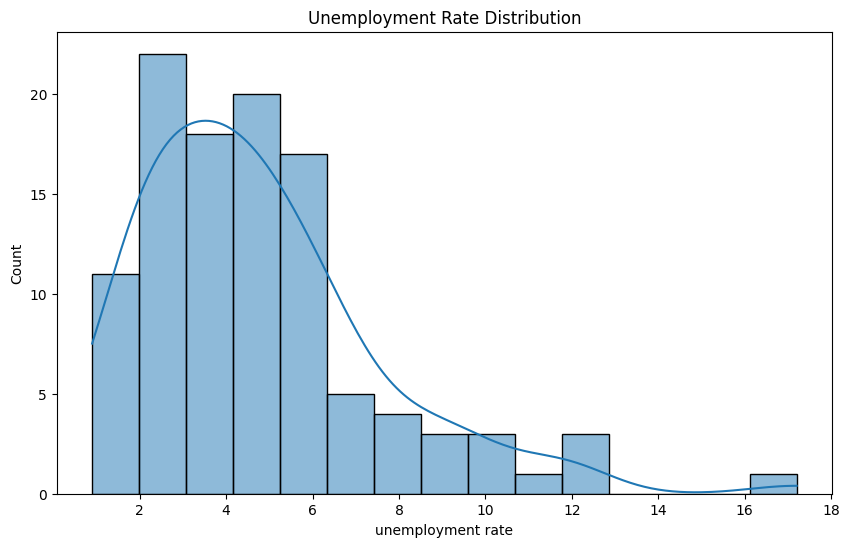

In [10]:
# ==========================================================
# 5.4 Literacy Distribution
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['unemployment rate'],
    bins=15,
    kde=True
)

plt.title("Unemployment Rate Distribution")
plt.show()

In [11]:
# ==========================================================
# 6. CORRELATION ANALYSIS
# ==========================================================

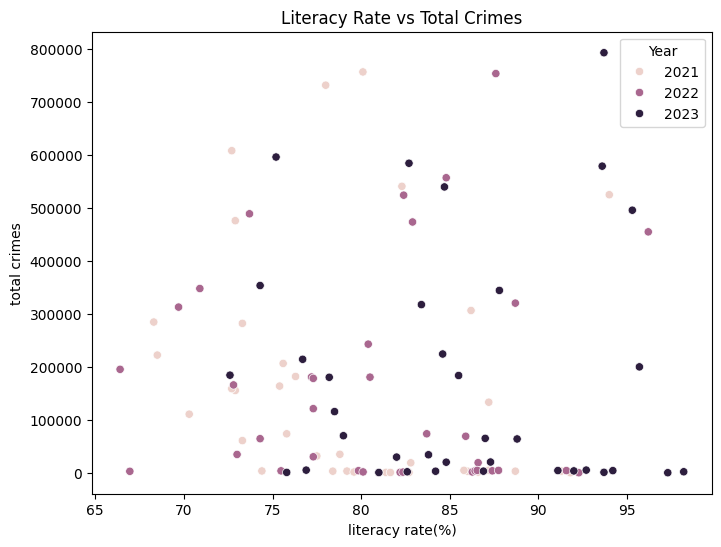

In [12]:
# ==========================================================
# LITERACY VS CRIME
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='literacy rate(%)',
    y='total crimes',
    data=df,
    hue='Year'
)

plt.title('Literacy Rate vs Total Crimes')
plt.show()

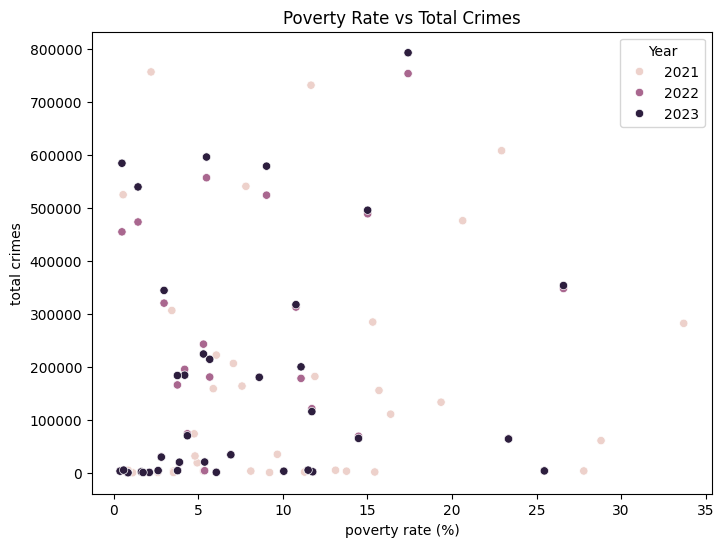

In [13]:
# ==========================================================
# POVERTY RATE VS CRIME
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='poverty rate (%)',
    y='total crimes',
    data=df,
    hue='Year'
)

plt.title('Poverty Rate vs Total Crimes')
plt.show()

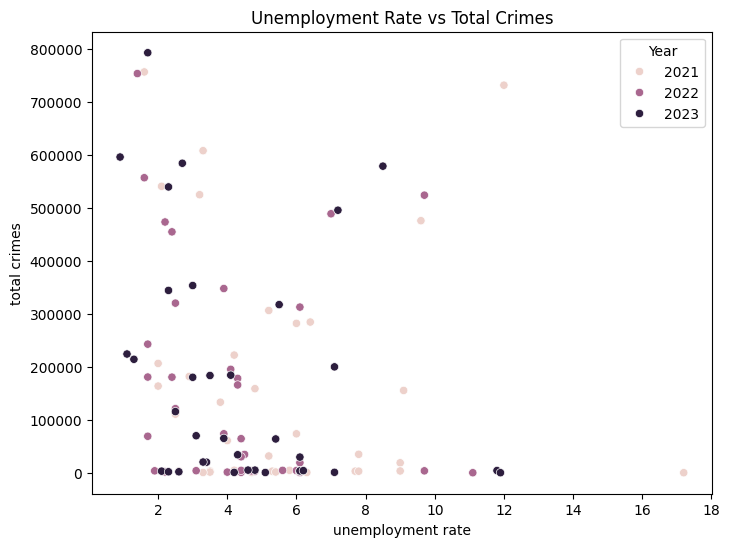

In [14]:
# ==========================================================
# Unemployment RATE VS CRIME
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='unemployment rate',
    y='total crimes',
    data=df,
    hue='Year'
)

plt.title('Unemployment Rate vs Total Crimes')
plt.show()

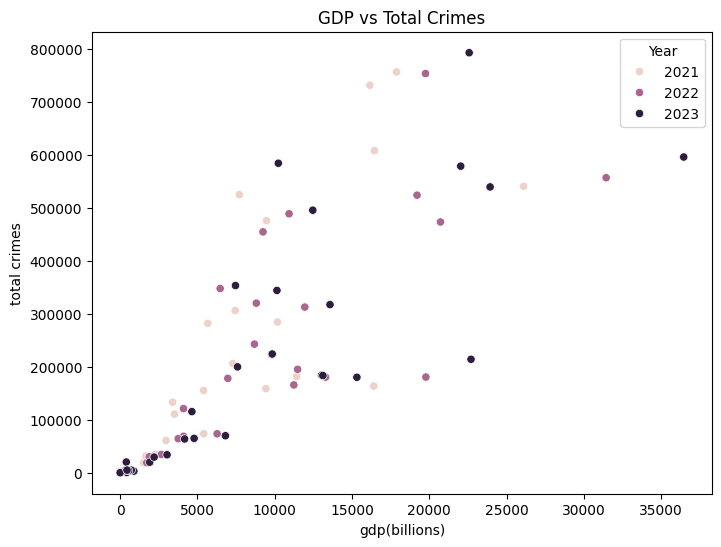

In [15]:
# ==========================================================
# Unemployment RATE VS CRIME
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='gdp(billions)',
    y='total crimes',
    data=df,
    hue='Year'
)

plt.title('GDP vs Total Crimes')
plt.show()

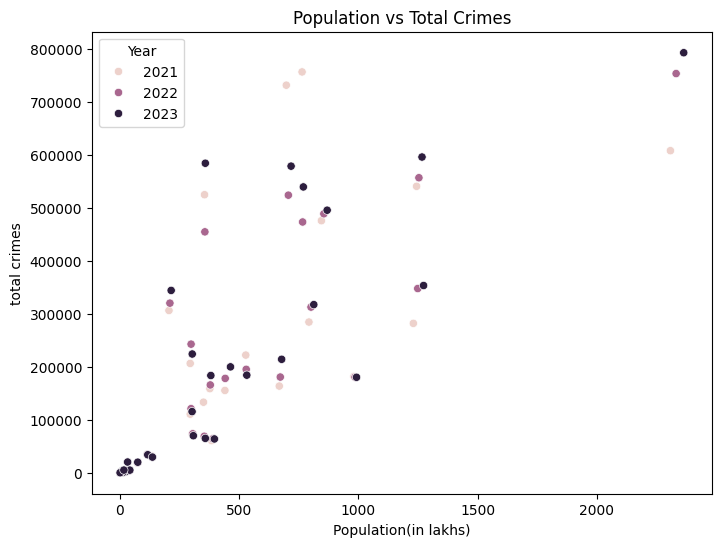

In [16]:
# ==========================================================
# Unemployment RATE VS CRIME
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Population(in lakhs)',
    y='total crimes',
    data=df,
    hue='Year'
)

plt.title('Population vs Total Crimes')
plt.show()

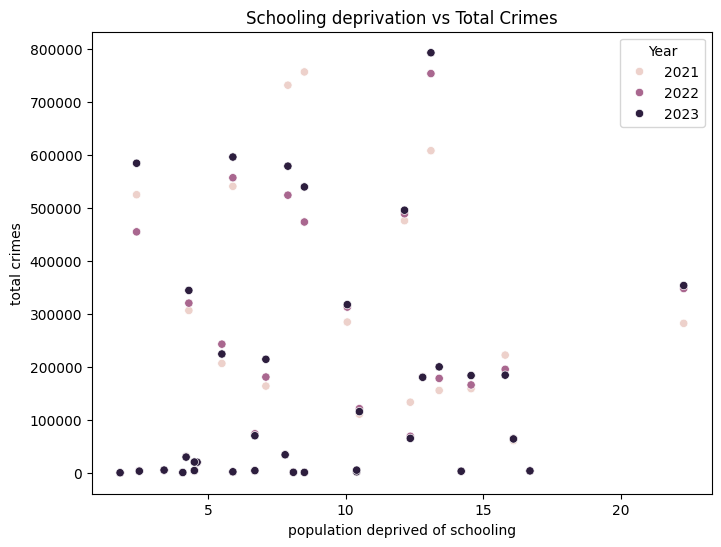

In [17]:
# ==========================================================
# Unemployment RATE VS CRIME
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='population deprived of schooling',
    y='total crimes',
    data=df,
    hue='Year'
)

plt.title('Schooling deprivation vs Total Crimes')
plt.show()

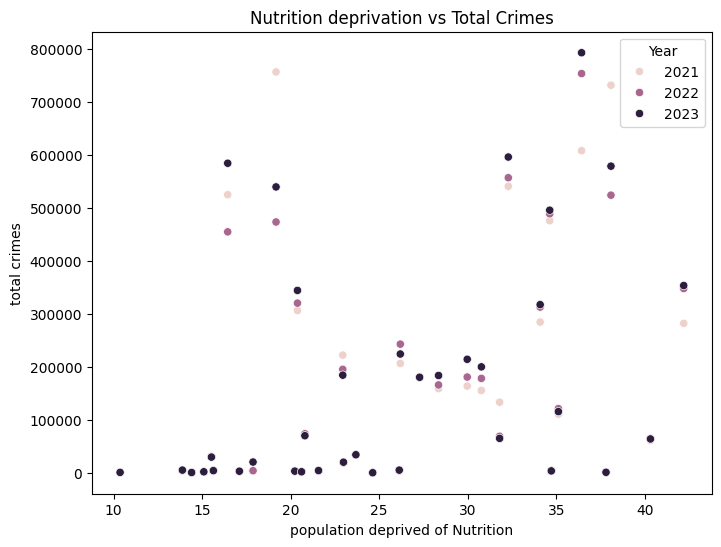

In [18]:
# ==========================================================
# Unemployment RATE VS CRIME
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='population deprived of Nutrition',
    y='total crimes',
    data=df,
    hue='Year'
)

plt.title('Nutrition deprivation vs Total Crimes')
plt.show()

In [19]:
# ==========================================================
# 6.3 Multi-Factor Correlation Analysis
# ==========================================================

features = [
    'poverty rate (%)',
    'literacy rate(%)',
    'unemployment rate',
    'gdp(billions)',
    'Population(in lakhs)',
    'population deprived of schooling',
    'population deprived of Nutrition'
]

print("\nFeature Correlation with Crime")

for feature in features:

    corr, p = pearsonr(
        df[feature],
        df['total crimes']
    )

    print(f"{feature}")
    print("Correlation:", corr)
    print("P-value:", p)
    print()


Feature Correlation with Crime
poverty rate (%)
Correlation: 0.14446348594803554
P-value: 0.13578417785300512

literacy rate(%)
Correlation: -0.055955339747492394
P-value: 0.5651632209941855

unemployment rate
Correlation: -0.17317376542830237
P-value: 0.07308483135475523

gdp(billions)
Correlation: 0.8339089804319018
P-value: 4.006528148366661e-29

Population(in lakhs)
Correlation: 0.8057580454470058
P-value: 7.329079012299481e-26

population deprived of schooling
Correlation: 0.14326327100364916
P-value: 0.1390995092526938

population deprived of Nutrition
Correlation: 0.39033563444382224
P-value: 2.9641968628247943e-05



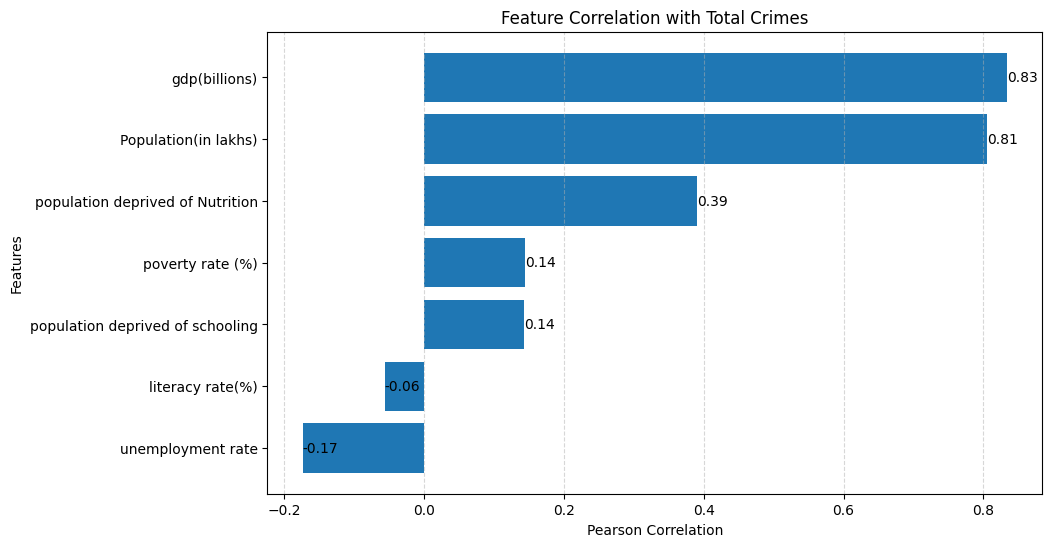

In [20]:
from scipy.stats import pearsonr
import pandas as pd
import matplotlib.pyplot as plt

# Features list
features = [
    'poverty rate (%)',
    'literacy rate(%)',
    'unemployment rate',
    'gdp(billions)',
    'Population(in lakhs)',
    'population deprived of schooling',
    'population deprived of Nutrition'
]

# Store correlation results
correlation_results = []

# Calculate correlations
for feature in features:
    
    corr, p = pearsonr(
        df[feature],
        df['total crimes']
    )
    
    correlation_results.append({
        'Feature': feature,
        'Correlation': corr,
        'P-value': p
    })

# Create dataframe
corr_df = pd.DataFrame(correlation_results)

# Sort by correlation strength
corr_df = corr_df.sort_values(by='Correlation')

# Plot
plt.figure(figsize=(10,6))

bars = plt.barh(
    corr_df['Feature'],
    corr_df['Correlation']
)

# Add correlation values on bars
for i, value in enumerate(corr_df['Correlation']):
    plt.text(
        value,
        i,
        f"{value:.2f}",
        va='center'
    )

plt.xlabel('Pearson Correlation')
plt.ylabel('Features')
plt.title('Feature Correlation with Total Crimes')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

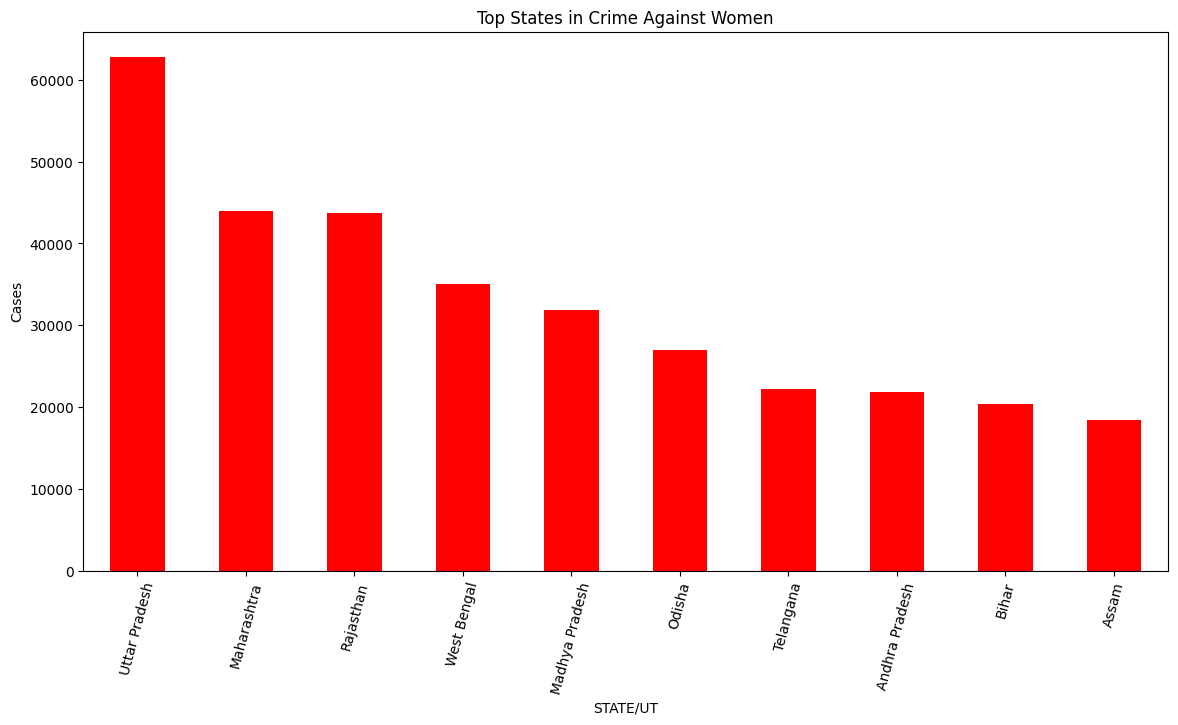

In [21]:
# ==========================================================
# CRIME AGAINST WOMEN
# ==========================================================

women_crime = df.groupby('STATE/UT')['crime against women'].mean()

women_crime = women_crime.sort_values(ascending=False)

plt.figure(figsize=(14,7))
women_crime.head(10).plot(kind='bar', color='red')

plt.title('Top States in Crime Against Women')
plt.ylabel('Cases')
plt.xticks(rotation=75)
plt.show()

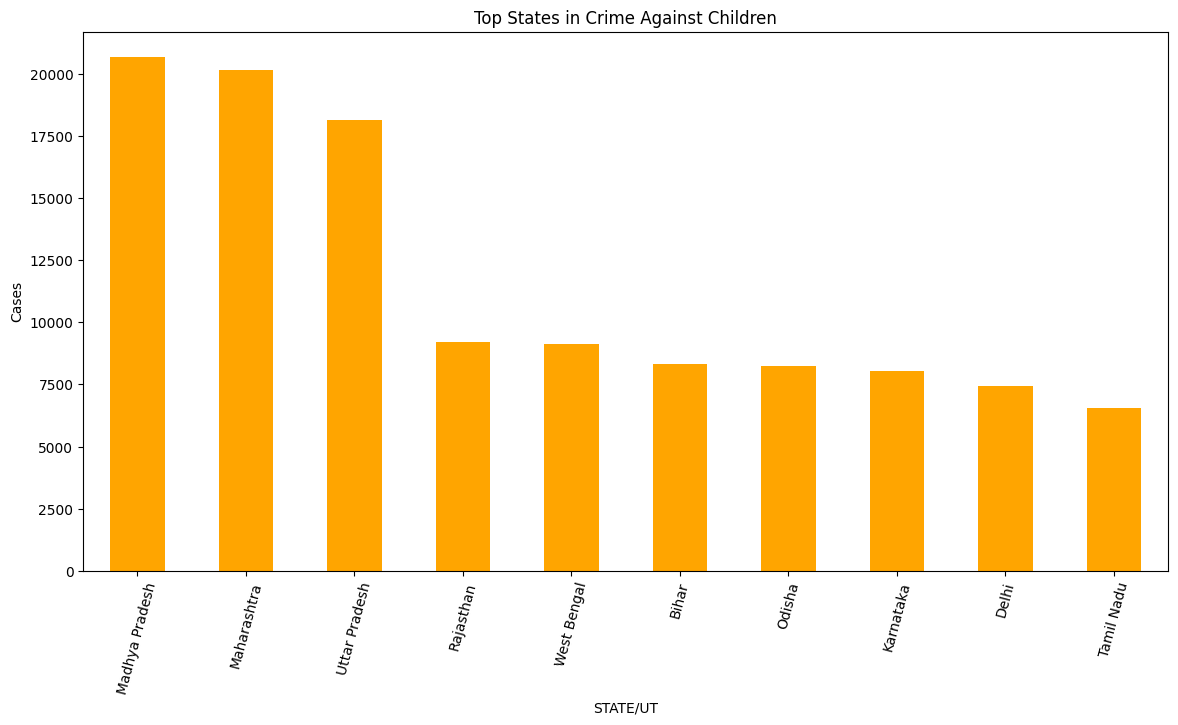

In [22]:
# ==========================================================
# CRIME AGAINST CHILDREN
# ==========================================================

child_crime = df.groupby('STATE/UT')['crime against children'].mean()

child_crime = child_crime.sort_values(ascending=False)

plt.figure(figsize=(14,7))
child_crime.head(10).plot(kind='bar', color='orange')

plt.title('Top States in Crime Against Children')
plt.ylabel('Cases')
plt.xticks(rotation=75)
plt.show()

In [23]:
# ==========================================================
# 7. CRIME ANALYTICS
# ==========================================================

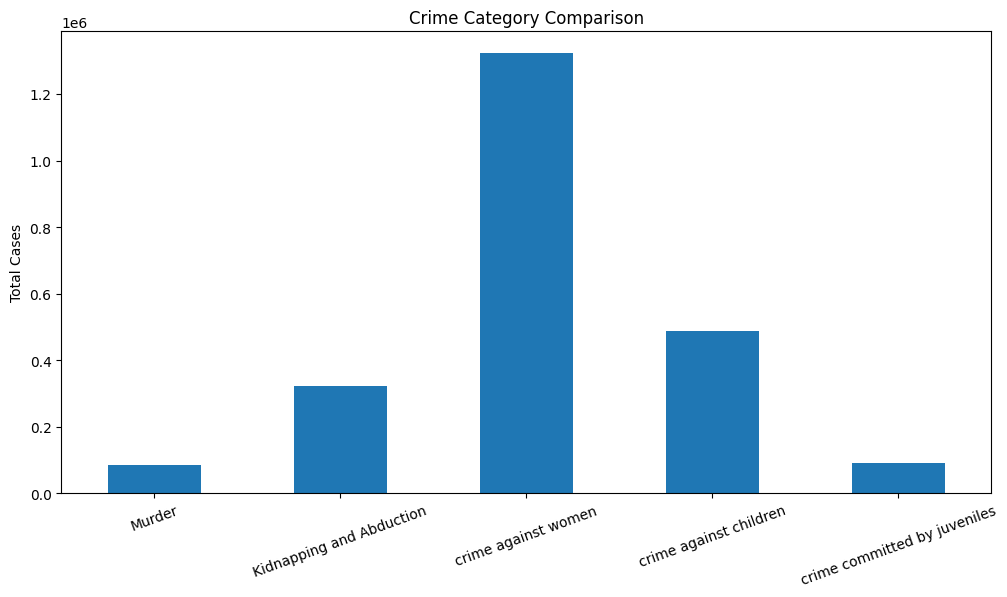

In [24]:
# ==========================================================
# 7.1 Crime Category Analysis
# ==========================================================

crime_columns = [
    'Murder',
    'Kidnapping and Abduction',
    'crime against women',
    'crime against children',
    'crime committed by juveniles'
]

crime_totals = df[crime_columns].sum()

plt.figure(figsize=(12,6))

crime_totals.plot(kind='bar')

plt.title("Crime Category Comparison")
plt.ylabel("Total Cases")
plt.xticks(rotation=20)

plt.show()

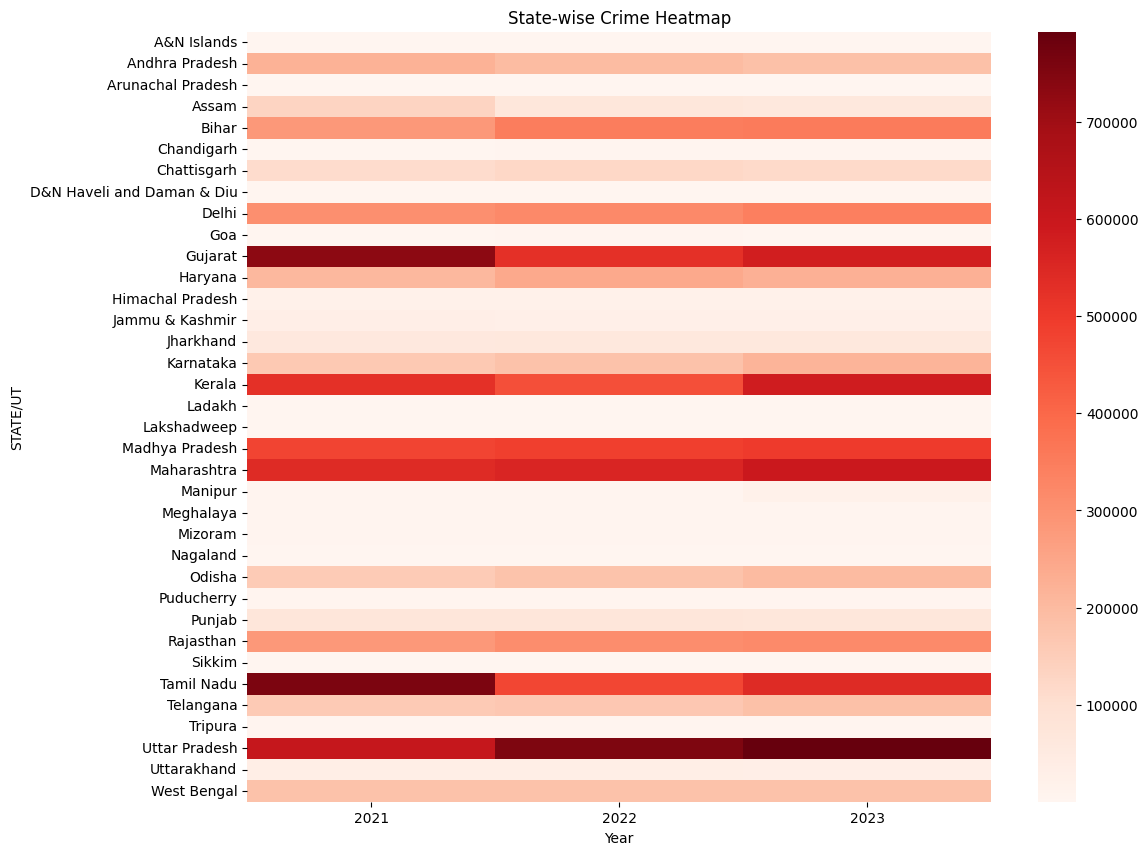

In [25]:
# ==========================================================
# 7.2 State-wise Crime Heatmap
# ==========================================================

state_crime = df.pivot_table(
    values='total crimes',
    index='STATE/UT',
    columns='Year'
)

plt.figure(figsize=(12,10))

sns.heatmap(
    state_crime,
    cmap='Reds'
)

plt.title("State-wise Crime Heatmap")
plt.show()


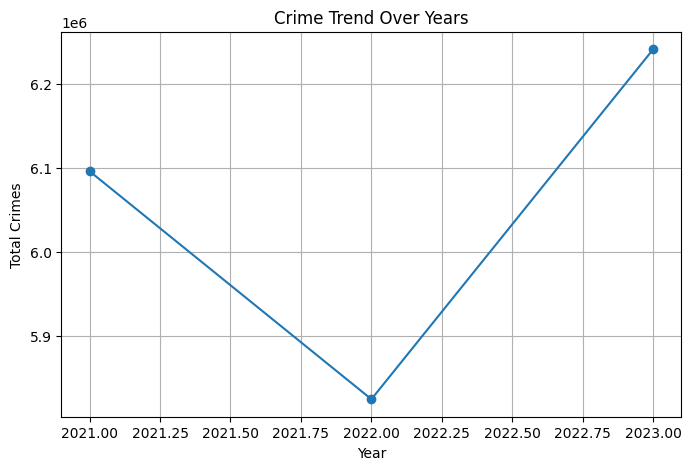

In [26]:
# ==========================================================
# YEARLY CRIME TREND
# ==========================================================

yearly_crime = df.groupby('Year')['total crimes'].sum()

plt.figure(figsize=(8,5))
plt.plot(yearly_crime.index, yearly_crime.values, marker='o')

plt.title('Crime Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Total Crimes')
plt.grid(True)
plt.show()

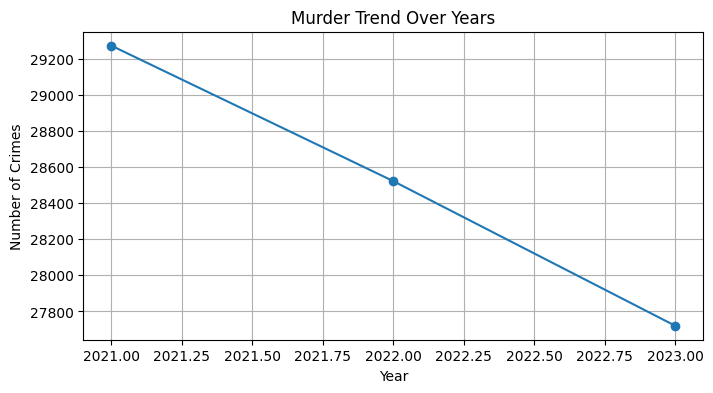

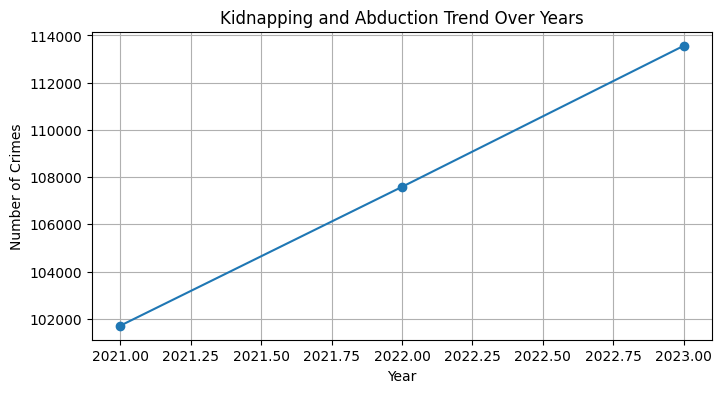

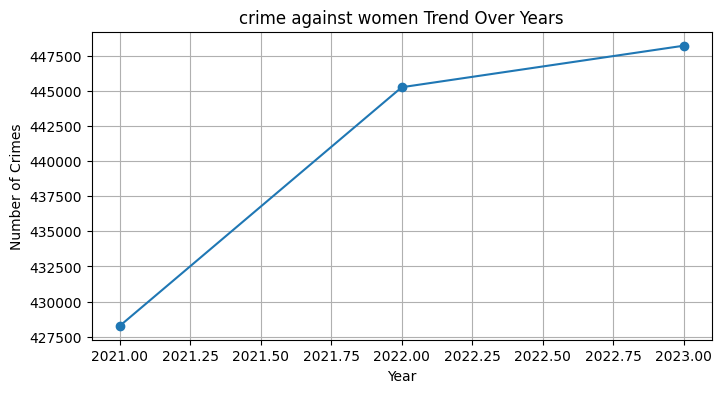

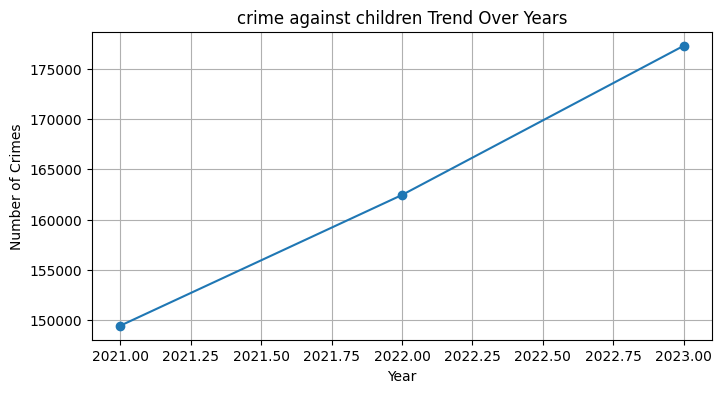

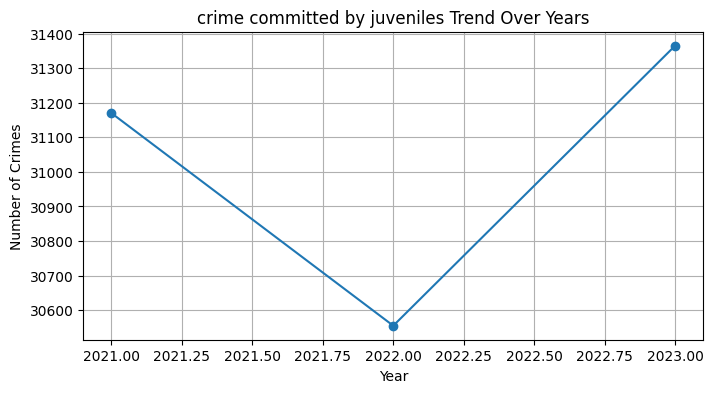

In [27]:
crime_columns = [
    'Murder',
    'Kidnapping and Abduction',
    'crime against women',
    'crime against children',
    'crime committed by juveniles'
]

crime_year = df.groupby('Year')[crime_columns].sum()

for col in crime_columns:
    plt.figure(figsize=(8,4))
    crime_year[col].plot(marker='o')

    plt.title(f"{col} Trend Over Years")
    plt.ylabel("Number of Crimes")
    plt.xlabel("Year")

    plt.grid(True)
    plt.show()

In [28]:
# ==========================================================
# 8. FEATURE ENGINEERING
# ==========================================================

In [29]:
# ==========================================================
# 8.1 Crime Per Lakh Population
# ==========================================================

df['Crime per Lakh Population'] = (
    df['total crimes'] /
    df['Population(in lakhs)']
)

df[['STATE/UT','Crime per Lakh Population']].head()

,STATE/UT,Crime per Lakh Population
0,Andhra Pradesh,420.935079
1,Arunachal Pradesh,198.238748
2,Assam,380.215735
3,Bihar,229.181122
4,Chattisgarh,375.116129


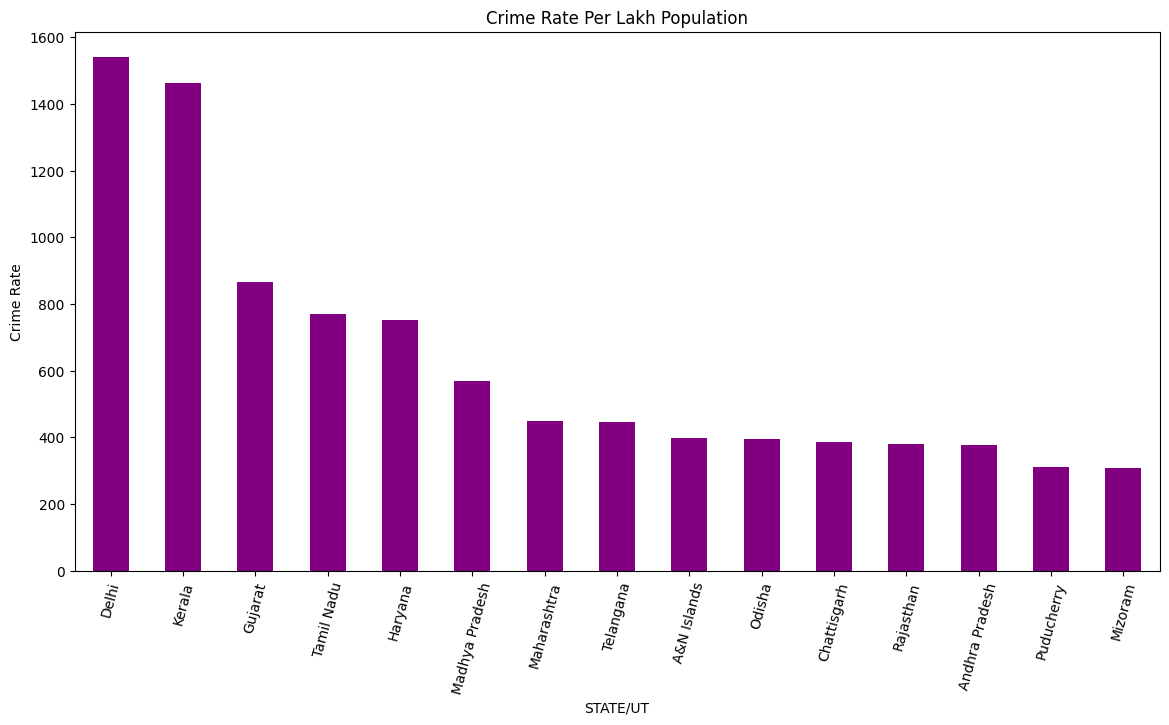

In [30]:
# ==========================================================
# CRIME RATE PER POPULATION
# ==========================================================

rate_df = df.groupby('STATE/UT')['Crime per Lakh Population'].mean()
rate_df = rate_df.sort_values(ascending=False)

plt.figure(figsize=(14,7))
rate_df.head(15).plot(kind='bar', color='purple')

plt.title('Crime Rate Per Lakh Population')
plt.ylabel('Crime Rate')
plt.xticks(rotation=75)
plt.show()

In [31]:
# ==========================================================
# 8.2 GDP Per Capita
# ==========================================================

df['GDP per Capita'] = (
    df['gdp(billions)'] /
    df['Population(in lakhs)']
)

print(df[[
    'STATE/UT',
    'GDP per Capita'
]].head())

            STATE/UT  GDP per Capita
0     Andhra Pradesh       18.538655
1  Arunachal Pradesh       19.895629
2              Assam        9.696658
3              Bihar        4.613147
4        Chattisgarh       11.945207


In [32]:
# ==========================================================
# 9. MACHINE LEARNING MODELS
# ==========================================================

ml_features = [
    'poverty rate (%)',
    'population deprived of schooling',
    'population deprived of Nutrition',
    'unemployment rate',
    'literacy rate(%)',
    'gdp(billions)',
    'Population(in lakhs)',
    'Crime per Lakh Population'
]

X = df[ml_features]
y = df['total crimes']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [33]:
# ==========================================================
# 9.1 Linear Regression
# ==========================================================

lr = LinearRegression()

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print("\nLINEAR REGRESSION")

print("MAE:",
      mean_absolute_error(y_test, pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, pred)))

print("R2 Score:",
      r2_score(y_test, pred))



LINEAR REGRESSION
MAE: 41201.4350242454
RMSE: 51418.2475529809
R2 Score: 0.9209782724029202


In [34]:
# ==========================================================
# 9.2 Random Forest
# ==========================================================

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nRANDOM FOREST")

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score:",
      r2_score(y_test, rf_pred))


RANDOM FOREST
MAE: 30176.070909090908
RMSE: 58281.19476484082
R2 Score: 0.8984759648276432


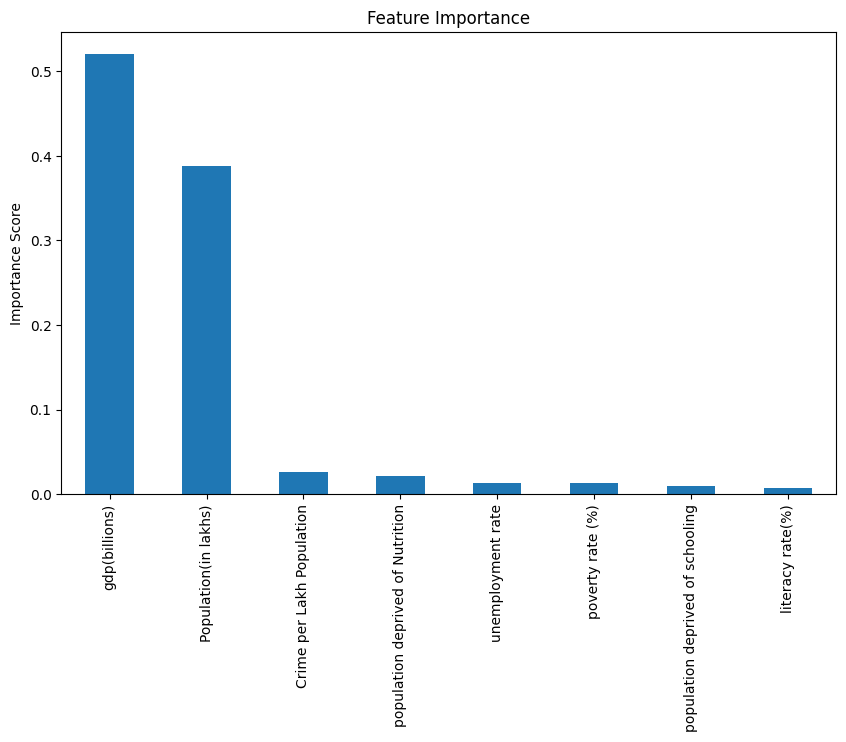


Feature Importance
gdp(billions)                       0.520300
Population(in lakhs)                0.388092
Crime per Lakh Population           0.026196
population deprived of Nutrition    0.021736
unemployment rate                   0.013123
poverty rate (%)                    0.012866
population deprived of schooling    0.009963
literacy rate(%)                    0.007723
dtype: float64


In [35]:
# ==========================================================
# 9.3 Feature Importance
# ==========================================================

importance = pd.Series(
    rf.feature_importances_,
    index=ml_features
)

importance = importance.sort_values(
    ascending=False
)

plt.figure(figsize=(10,6))

importance.plot(kind='bar')

plt.title("Feature Importance")
plt.ylabel("Importance Score")

plt.show()

print("\nFeature Importance")
print(importance)


In [36]:
# ==========================================================
# OUTLIER DETECTION
# ==========================================================

features = df[[
    'total crimes',
    'population deprived of schooling',
    'poverty rate (%)',
    'population deprived of Nutrition',
    'unemployment rate',
    'gdp(billions)',
    'literacy rate(%)',
    'Population(in lakhs)',
    'total crimes',
    'Murder',
    'Kidnapping and Abduction',
    'crime against women',
    'crime against children',
    'crime committed by juveniles'
]]

iso = IsolationForest(contamination=0.1, random_state=42)

df['outlier'] = iso.fit_predict(features)

outliers = df[df['outlier'] == -1]

print(outliers[['STATE/UT', 'total crimes']])

          STATE/UT  total crimes
3            Bihar        282083
6          Gujarat        731738
12  Madhya Pradesh        475918
13     Maharashtra        540800
25   Uttar Pradesh        608082
39           Bihar        347835
49     Maharashtra        557012
61   Uttar Pradesh        753675
75           Bihar        353502
85     Maharashtra        596103
97   Uttar Pradesh        793020


            STATE/UT  Cluster
0     Andhra Pradesh      0.0
1  Arunachal Pradesh      1.0
2              Assam      0.0
3              Bihar      0.0
4        Chattisgarh      0.0


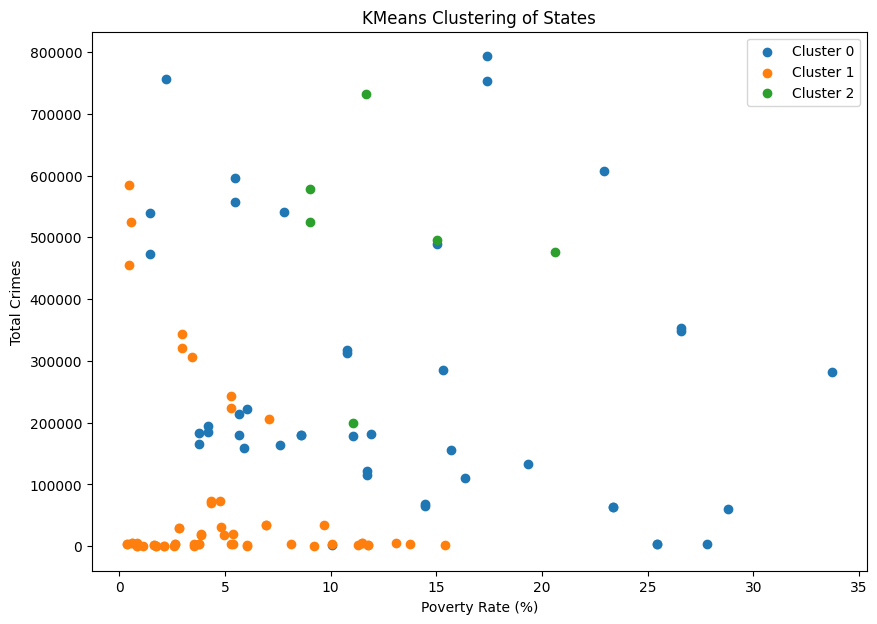

In [37]:
# ==========================================================
# K-MEANS CLUSTERING
# ==========================================================

features = [
    "poverty rate (%)",
    "unemployment rate",
    "literacy rate(%)",
    "Population(in lakhs)",
    "total crimes",
    "crime against women",
    "crime against children"
]

# Standardize data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels
df.loc[X.index, "Cluster"] = clusters

# Show results
print(df[["STATE/UT", "Cluster"]].head())

# Visualization

plt.figure(figsize=(10,7))

# Plot each cluster separately
for cluster in sorted(df["Cluster"].dropna().unique()):
    
    cluster_data = df[df["Cluster"] == cluster]
    
    plt.scatter(
        cluster_data["poverty rate (%)"],
        cluster_data["total crimes"],
        label=f"Cluster {int(cluster)}"
    )

plt.title("KMeans Clustering of States")

plt.xlabel("Poverty Rate (%)")

plt.ylabel("Total Crimes")

# Add legend
plt.legend()

plt.show()

In [38]:
# Add cluster labels to dataframe
df['Cluster'] = kmeans.labels_

# Display states in each cluster
for cluster in sorted(df['Cluster'].unique()):
    print(f"\n===== Cluster {cluster} =====")
    print(df[df['Cluster'] == cluster]['STATE/UT'].values)


===== Cluster 0 =====
['Andhra Pradesh' 'Assam' 'Bihar' 'Chattisgarh' 'Jharkhand' 'Karnataka'
 'Maharashtra' 'Meghalaya' 'Odisha' 'Rajasthan' 'Tamil Nadu' 'Telangana'
 'Uttar Pradesh' 'West Bengal' 'Andhra Pradesh' 'Arunachal Pradesh'
 'Assam' 'Bihar' 'Chattisgarh' 'Jharkhand' 'Karnataka' 'Madhya Pradesh'
 'Maharashtra' 'Meghalaya' 'Odisha' 'Rajasthan' 'Tamil Nadu' 'Telangana'
 'Uttar Pradesh' 'West Bengal' 'Andhra Pradesh' 'Assam' 'Bihar'
 'Chattisgarh' 'Jharkhand' 'Karnataka' 'Maharashtra' 'Meghalaya'
 'Rajasthan' 'Tamil Nadu' 'Telangana' 'Uttar Pradesh' 'West Bengal']

===== Cluster 1 =====
['Arunachal Pradesh' 'Goa' 'Haryana' 'Himachal Pradesh' 'Kerala' 'Manipur'
 'Mizoram' 'Nagaland' 'Punjab' 'Sikkim' 'Tripura' 'Uttarakhand'
 'A&N Islands' 'Chandigarh' 'D&N Haveli and Daman & Diu' 'Delhi'
 'Jammu & Kashmir' 'Ladakh' 'Lakshadweep' 'Puducherry' 'Goa' 'Haryana'
 'Himachal Pradesh' 'Kerala' 'Manipur' 'Mizoram' 'Nagaland' 'Punjab'
 'Sikkim' 'Tripura' 'Uttarakhand' 'A&N Islands' 'Chand

In [39]:
K-Means clustering was applied to group states with similar socio-economic 
and crime characteristics. The clustering analysis helped identify high-risk 
regions and revealed hidden patterns in crime distribution across India.
    
K-Means clustering can be very useful in your crime and socio-economic dataset because 
it helps you group states or regions with similar crime and socio-economic characteristics 
without needing predefined labels.

Instead of predicting something, K-Means helps answer questions like:

Which states have similar crime patterns?
Which regions are socio-economically similar?
Which states belong to high-risk crime clusters?
Which states have similar combinations of poverty, unemployment, and crime?

SyntaxError: invalid syntax (2360891426.py, line 1)

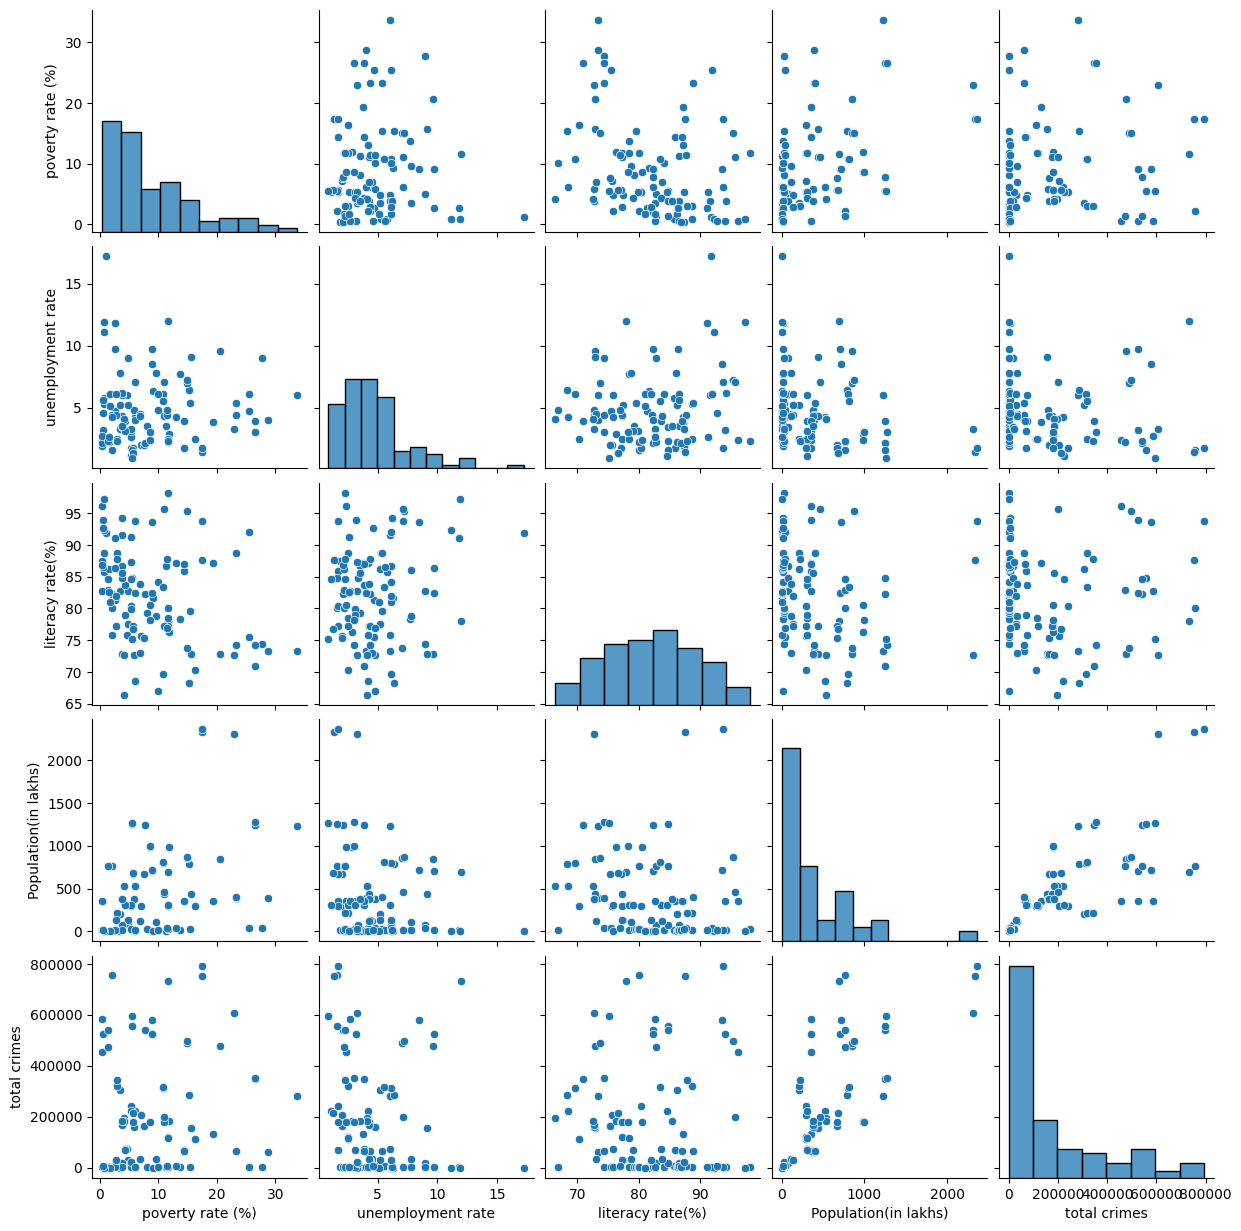

In [40]:
# Selected columns
columns = [
    "poverty rate (%)",
    "unemployment rate",
    "literacy rate(%)",
    "Population(in lakhs)",
    "total crimes"
]

sns.pairplot(df[columns])
plt.show()

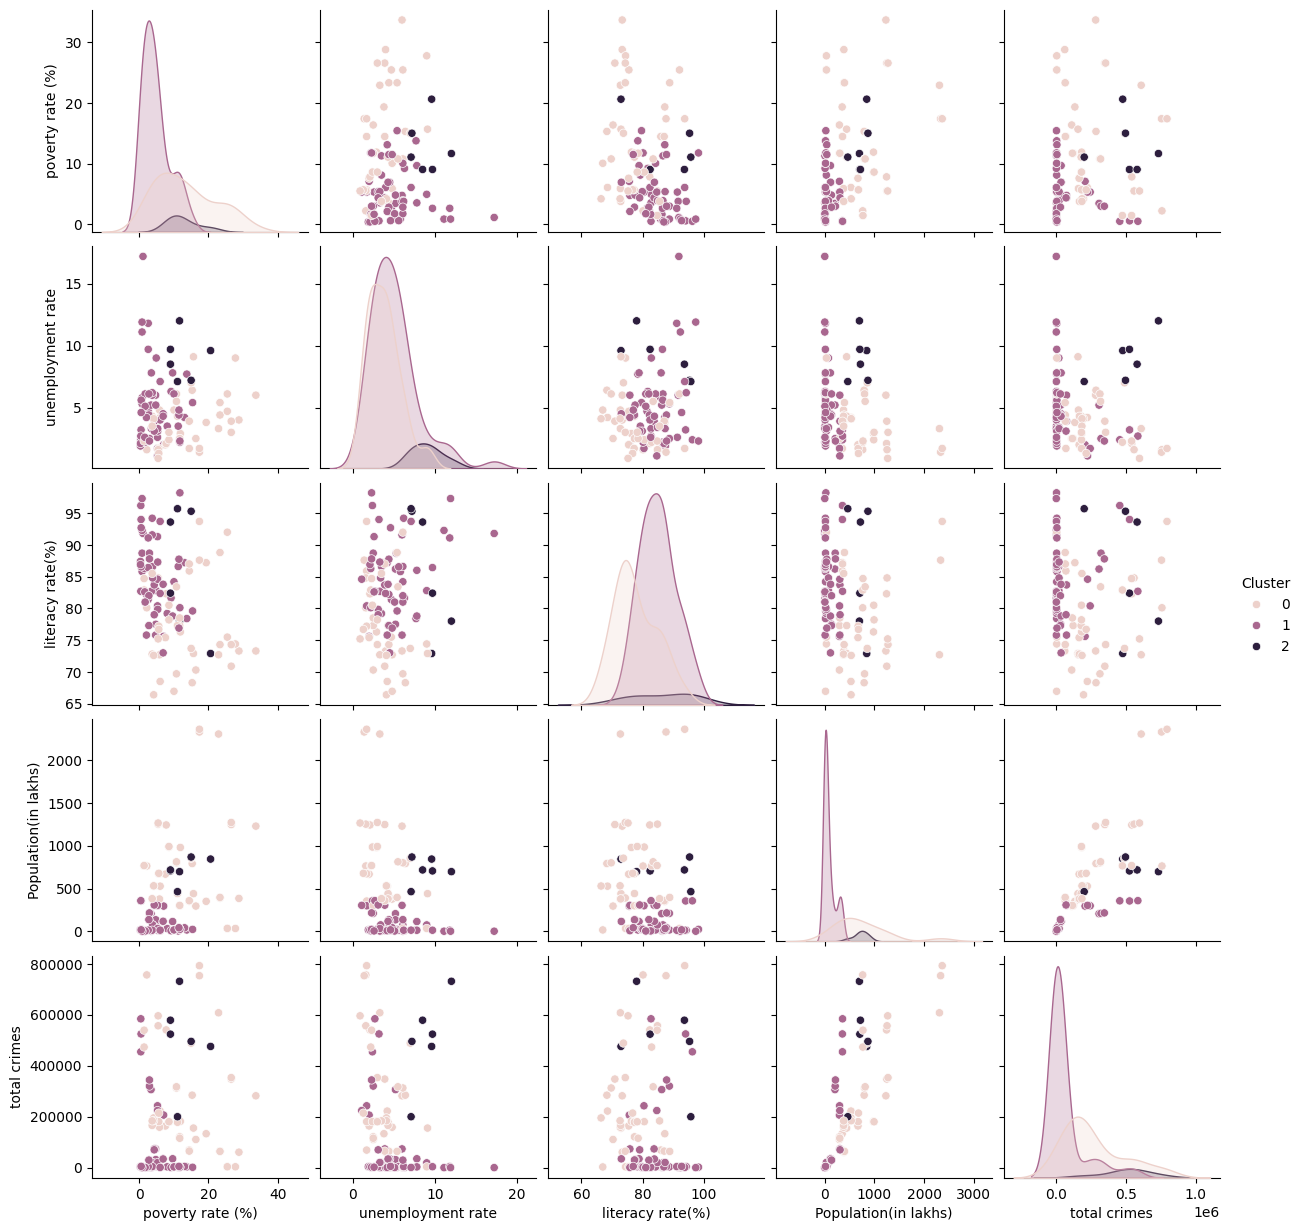

In [41]:
sns.pairplot(
    df,
    vars=columns,
    hue="Cluster"
)

plt.show()

In [42]:
Pairplot visualization was used to examine pairwise relationships among socio-economic and 
crime-related variables. The analysis helped identify trends, correlations, clusters, and 
potential outliers across different states. 
A pairplot is very useful in your crime and socio-economic dataset because it helps us
visualize relationships between multiple variables simultaneously. Instead of checking one 
graph at a time, a pairplot provides a complete overview of:

correlations
trends
distributions
clusters
outliers

across all important factors in a single visualization.

For our dataset, which contains variables such as:

poverty rate
unemployment rate
literacy rate
population
total crimes
crimes against women
crimes against children

a pairplot helps identify how these variables interact with each other.

SyntaxError: invalid syntax (2425039250.py, line 1)

In [ ]:
# Group yearly total crimes
yearly_crime = df.groupby('Year')['total crimes'].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    yearly_crime.index,
    yearly_crime.values,
    marker='o',
    label='Historical'
)

plt.xlabel('Year')
plt.ylabel('Total Crimes')
plt.title('Historical Crime Trend')

plt.legend()
plt.grid(True)

plt.show()

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packag

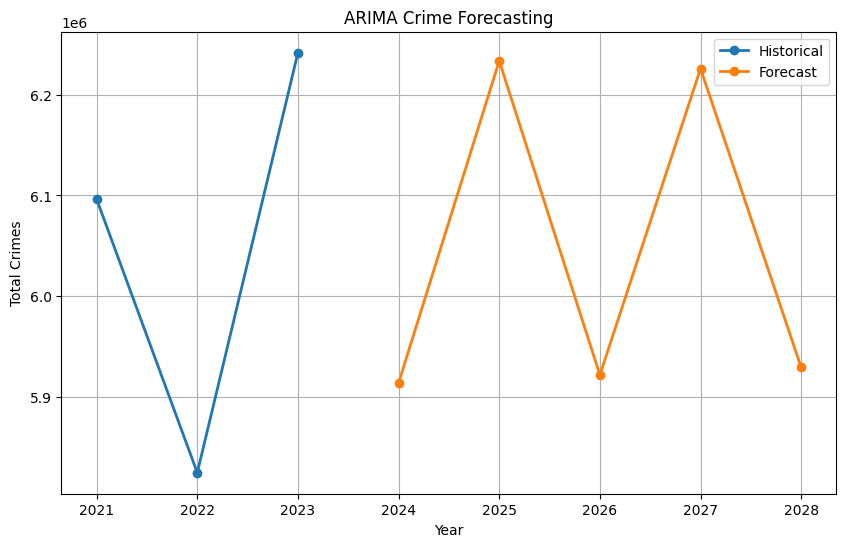

ARIMA(1,1,1) Model
Forecasts next 5 years based on historical crime patterns.
Forecast suggests a decrease in crime trend.


In [43]:
from statsmodels.tsa.arima.model import ARIMA

# Train model
model = ARIMA(yearly_crime, order=(1,1,1))

model_fit = model.fit()

# Forecast next 5 years
forecast = model_fit.forecast(steps=5)


# Future years
future_years = range(
    yearly_crime.index.max() + 1,
    yearly_crime.index.max() + 6
)

plt.figure(figsize=(10,6))

# Historical data
plt.plot(
    yearly_crime.index,
    yearly_crime.values,
    marker='o',
    linewidth=2,
    label='Historical'
)

# Forecast data
plt.plot(
    future_years,
    forecast,
    marker='o',
    linewidth=2,
    label='Forecast'
)

plt.xlabel('Year')
plt.ylabel('Total Crimes')

plt.title('ARIMA Crime Forecasting')

plt.legend()
plt.grid(True)

plt.show()

print("ARIMA(1,1,1) Model")
print("Forecasts next 5 years based on historical crime patterns.")

if forecast.iloc[-1] > yearly_crime.values[-1]:
    print("Forecast suggests an increase in crime trend.")
else:
    print("Forecast suggests a decrease in crime trend.")


Top 5 Safest States:
       STATE/UT  Crime Risk Index
9           Goa          1.164887
17       Ladakh          1.834031
29       Sikkim          1.854434
26   Puducherry          1.932183
0   A&N Islands          2.142707

Detected Anomalies:
          STATE/UT  Year  Crime Risk Index
3            Bihar  2021         47.425708
12  Madhya Pradesh  2021         61.157967
25   Uttar Pradesh  2021         75.603939
61   Uttar Pradesh  2022         82.144616
85     Maharashtra  2023         64.992261
97   Uttar Pradesh  2023         83.096862


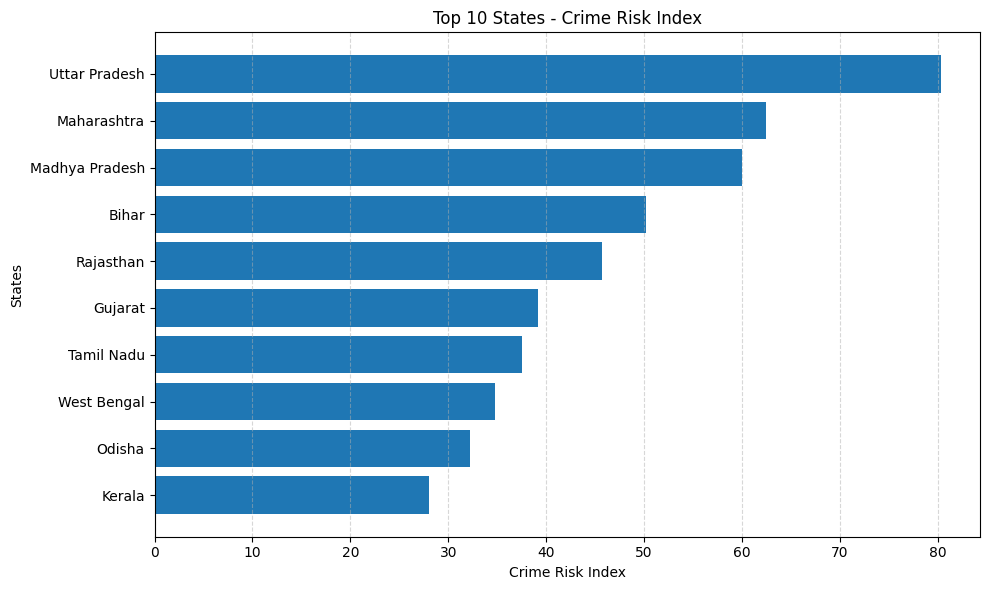

In [46]:
from sklearn.preprocessing import MinMaxScaler
# --------------------------------------------
# FEATURES FOR CRIME RISK INDEX
# --------------------------------------------

crime_features = [
    'total crimes',
    'Murder',
    'Kidnapping and Abduction',
    'crime against women',
    'crime against children',
    'crime committed by juveniles',
    'poverty rate (%)',
    'unemployment rate'
]

# --------------------------------------------
# NORMALIZE FEATURES
# --------------------------------------------

scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(df[crime_features])

# --------------------------------------------
# ASSIGN WEIGHTS
# --------------------------------------------

weights = np.array([
    0.30,  # total crimes
    0.15,  # murder
    0.10,  # kidnapping
    0.15,  # crimes against women
    0.10,  # crimes against children
    0.05,  # juvenile crimes
    0.10,  # poverty
    0.05   # unemployment
])

# --------------------------------------------
# CALCULATE CRIME RISK INDEX
# --------------------------------------------

df['Crime Risk Index'] = (
    scaled_features * weights
).sum(axis=1) * 100

# --------------------------------------------
# AVERAGE RISK BY STATE
# --------------------------------------------

state_risk = (
    df.groupby('STATE/UT')['Crime Risk Index']
    .mean()
    .reset_index()
)

# Sort from highest risk to lowest
state_risk = state_risk.sort_values(
    by='Crime Risk Index',
    ascending=False
)

# --------------------------------------------
# TOP 5 SAFEST STATES
# --------------------------------------------

safest_states = (
    state_risk.sort_values(by='Crime Risk Index')
    .head(5)
)

print("\nTop 5 Safest States:")
print(safest_states)

# --------------------------------------------
# ANOMALY DETECTION
# --------------------------------------------

anomaly_features = [
    'total crimes',
    'Murder',
    'Kidnapping and Abduction',
    'crime against women',
    'crime against children',
    'crime committed by juveniles',
    'poverty rate (%)',
    'unemployment rate'
]

# Isolation Forest Model
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Fit model
df['Anomaly'] = iso.fit_predict(df[anomaly_features])

# -1 = anomaly
anomalies = df[df['Anomaly'] == -1]

print("\nDetected Anomalies:")
print(
    anomalies[
        ['STATE/UT', 'Year', 'Crime Risk Index']
    ]
)

# --------------------------------------------
# VISUALIZATION
# --------------------------------------------

top10 = state_risk.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10['STATE/UT'][::-1],
    top10['Crime Risk Index'][::-1]
)

plt.xlabel("Crime Risk Index")
plt.ylabel("States")
plt.title("Top 10 States - Crime Risk Index")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [25]:
# ==========================================================
# 18. FINAL INSIGHTS
# ==========================================================

print("\nSTATE WITH HIGHEST CRIME")

print(
    df.groupby('STATE/UT')['total crimes']
    .mean()
    .idxmax()
)

print("\nSTATE WITH HIGHEST LITERACY")

print(
    df.groupby('STATE/UT')['literacy rate(%)']
    .mean()
    .idxmax()
)

print("\nSTATE WITH HIGHEST POVERTY")

print(
    df.groupby('STATE/UT')['poverty rate (%)']
    .mean()
    .idxmax()
)



STATE WITH HIGHEST CRIME
Uttar Pradesh

STATE WITH HIGHEST LITERACY
Lakshadweep

STATE WITH HIGHEST POVERTY
Bihar


In [46]:
# ==========================================================
# STATE RANKING
# ==========================================================

ranking_df = df.groupby('STATE/UT')['total crimes'].mean().reset_index()

ranking_df['Rank'] = ranking_df['total crimes'].rank(ascending=False)

ranking_df.sort_values('Rank').head(10)

,STATE/UT,total crimes,Rank
33,Uttar Pradesh,718259.000000,1.0
10,Gujarat,611573.333333,2.0
30,Tamil Nadu,589953.333333,3.0
20,Maharashtra,564638.333333,4.0
16,Kerala,521389.666667,5.0
19,Madhya Pradesh,486864.000000,6.0
4,Bihar,327806.666667,7.0
8,Delhi,323642.000000,8.0
28,Rajasthan,304951.000000,9.0
11,Haryana,224498.666667,10.0


In [ ]:
# 32. Recommendations Section

## Policy Recommendations

### 1. Improve Education

Higher literacy may help reduce crime.

### 2. Poverty Reduction Programs

States with higher poverty may need stronger welfare support.

### 3. Women Safety Programs

Crime against women needs stricter law enforcement.

### 4. Child Protection Measures

High child crime regions need awareness and monitoring.

### 5. Employment Opportunities

Reducing unemployment may lower crime growth.



# 33. Final Conclusion

## Conclusion

This project successfully analyzed crime trends across Indian states using advanced Data Science and Machine Learning techniques.

Major findings include:

* Population significantly affects total crime volume.
* Poverty and unemployment influence crime patterns.
* Literacy rate shows relationship with crime reduction.
* Certain states consistently show higher crime concentration.
* Random Forest provided better prediction performance than Linear Regression.
* Clustering revealed groups of states with similar socio-economic and crime characteristics.

The project demonstrates practical applications of:

* Data Cleaning
* Exploratory Data Analysis
* Statistical Testing
* Machine Learning
* Clustering
